Distrutions_compare  توصیف های اماری

![alt text](image.png)

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.stats import poisson
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
p = [0.10, 0.41, 0, 0.334]
q = [0.11, 0.45, 0.12, 0.345]

In [3]:
# کولبک لیبل دایورجنس
def kl(p, q):
    result = np.sum(np.where(np.logical_and(p != 0, q != 0), p * np.log(p / q), 0))
    return result

In [4]:
x = np.arange(-10, 10, 0.001)
len(x)

20000

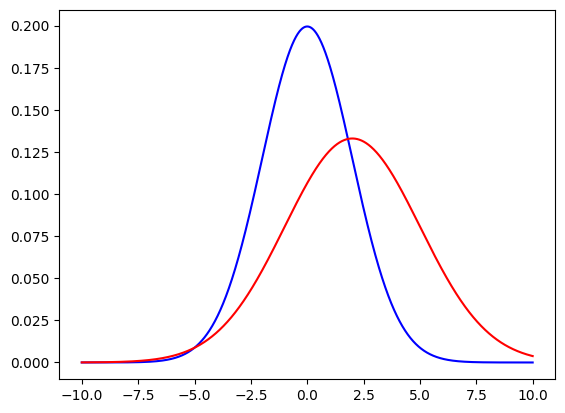

In [5]:
p = norm.pdf(x, 0, 2)
q = norm.pdf(x, 2, 3)
plt.plot(x, p, c='blue')
plt.plot(x, q, c='red')

In [6]:
kl(p, q)

np.float64(349.9134833786811)

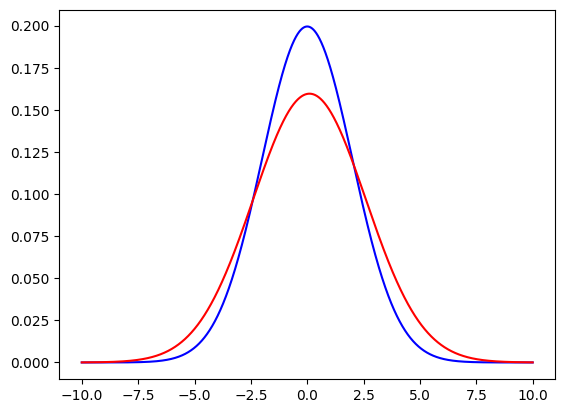

In [7]:
p = norm.pdf(x, 0, 2)
q = norm.pdf(x, 0.1, 2.5)
plt.plot(x, p, c='blue')
plt.plot(x, q, c='red')

In [8]:
kl(p, q)

np.float64(43.946202336535066)

In [9]:
data = pd.read_csv('weight-height.csv')
data.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [10]:
data.groupby('Gender').mean()

,Height,Weight
Gender,,
Female,63.708774,135.860093
Male,69.026346,187.020621


<Axes: >

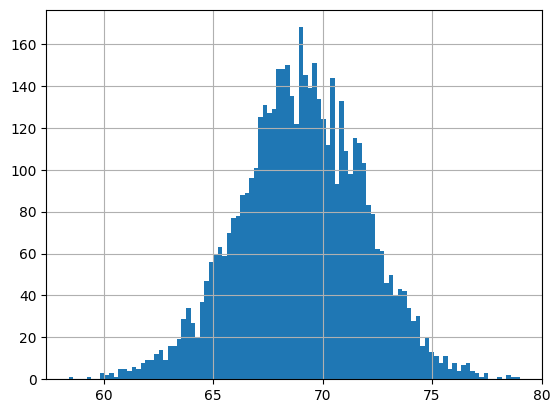

In [11]:
males = data[data['Gender'] == 'Male']['Height']
males.hist(bins=100)

In [12]:
males.describe()['mean']

np.float64(69.02634590621741)

In [13]:
males.describe()['std']

np.float64(2.863362228660647)

In [14]:
count, devision = np.histogram(males, bins=100)
print(count)
print(devision)

[  1   0   0   0   1   0   0   3   2   3   1   5   5   4   6   5   8   9
   9  12  14   9  16  16  19  29  34  27  20  37  47  56  60  63  59  70
  77  78  88  89  96 101 125 131 127 129 148 148 150 135 122 168 145 139
 151 134 124 112 144  93 133 109  98 115 113 103  83  79  62  61  46  50
  40  43  42  34  28  30  16  20  13  11   8  11   5   8   4   7   8   4
   3   1   3   0   0   1   0   2   1   1]
[58.40690493 58.61282331 58.81874168 59.02466005 59.23057843 59.4364968
 59.64241518 59.84833355 60.05425192 60.2601703  60.46608867 60.67200705
 60.87792542 61.0838438  61.28976217 61.49568054 61.70159892 61.90751729
 62.11343567 62.31935404 62.52527241 62.73119079 62.93710916 63.14302754
 63.34894591 63.55486429 63.76078266 63.96670103 64.17261941 64.37853778
 64.58445616 64.79037453 64.9962929  65.20221128 65.40812965 65.61404803
 65.8199664  66.02588478 66.23180315 66.43772152 66.6436399  66.84955827
 67.05547665 67.26139502 67.46731339 67.67323177 67.87915014 68.08506852
 68.290986

In [15]:
ideal = norm.rvs(size=len(males), loc=males.describe()['mean'], scale=males.describe()['std'])
print(ideal)

[66.30583812 68.85855609 64.78487798 ... 69.53500073 72.97260882
 69.22151771]


In [16]:
icount, idevision = np.histogram(ideal, bins=100)
print(icount)
print(idevision)

[  1   0   1   1   1   1   3   2   1   2   6   5   2   5   9   5   7   5
   9   8  18  18  16  23  28  32  29  42  37  47  44  73  63  67  67  83
  85  97 107 107 107 115 136 119 119 130 131 125 122 143 138 135 131 135
 128 129 115 128 134 116 116 113  82 104  83  78  77  63  74  76  52  43
  32  37  45  23  37  27  23  24  15  15  10   7  10   7   6   7   5   3
   5   2   1   0   2   1   1   0   0   1]
[58.81388448 59.01502554 59.2161666  59.41730765 59.61844871 59.81958976
 60.02073082 60.22187187 60.42301293 60.62415398 60.82529504 61.02643609
 61.22757715 61.4287182  61.62985926 61.83100031 62.03214137 62.23328242
 62.43442348 62.63556453 62.83670559 63.03784664 63.2389877  63.44012875
 63.64126981 63.84241086 64.04355192 64.24469298 64.44583403 64.64697509
 64.84811614 65.0492572  65.25039825 65.45153931 65.65268036 65.85382142
 66.05496247 66.25610353 66.45724458 66.65838564 66.85952669 67.06066775
 67.2618088  67.46294986 67.66409091 67.86523197 68.06637302 68.26751408
 68.46865

(array([  1.,   0.,   1.,   1.,   1.,   1.,   3.,   2.,   1.,   2.,   6.,
          5.,   2.,   5.,   9.,   5.,   7.,   5.,   9.,   8.,  18.,  18.,
         16.,  23.,  28.,  32.,  29.,  42.,  37.,  47.,  44.,  73.,  63.,
         67.,  67.,  83.,  85.,  97., 107., 107., 107., 115., 136., 119.,
        119., 130., 131., 125., 122., 143., 138., 135., 131., 135., 128.,
        129., 115., 128., 134., 116., 116., 113.,  82., 104.,  83.,  78.,
         77.,  63.,  74.,  76.,  52.,  43.,  32.,  37.,  45.,  23.,  37.,
         27.,  23.,  24.,  15.,  15.,  10.,   7.,  10.,   7.,   6.,   7.,
          5.,   3.,   5.,   2.,   1.,   0.,   2.,   1.,   1.,   0.,   0.,
          1.]),
 array([58.81388448, 59.01502554, 59.2161666 , 59.41730765, 59.61844871,
        59.81958976, 60.02073082, 60.22187187, 60.42301293, 60.62415398,
        60.82529504, 61.02643609, 61.22757715, 61.4287182 , 61.62985926,
        61.83100031, 62.03214137, 62.23328242, 62.43442348, 62.63556453,
        62.83670559, 63.03

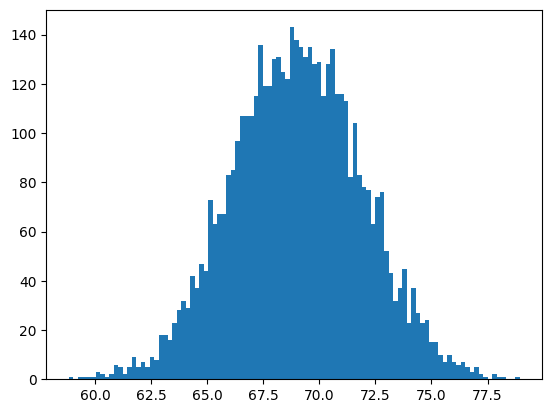

In [17]:
plt.hist(ideal, bins=100)

In [18]:
kl(count, icount)

C:\Users\Taha\AppData\Local\Temp\ipykernel_6756\159355123.py:3: RuntimeWarning: divide by zero encountered in divide
  result = np.sum(np.where(np.logical_and(p != 0, q != 0), p * np.log(p / q), 0))
C:\Users\Taha\AppData\Local\Temp\ipykernel_6756\159355123.py:3: RuntimeWarning: invalid value encountered in divide
  result = np.sum(np.where(np.logical_and(p != 0, q != 0), p * np.log(p / q), 0))
C:\Users\Taha\AppData\Local\Temp\ipykernel_6756\159355123.py:3: RuntimeWarning: divide by zero encountered in log
  result = np.sum(np.where(np.logical_and(p != 0, q != 0), p * np.log(p / q), 0))
C:\Users\Taha\AppData\Local\Temp\ipykernel_6756\159355123.py:3: RuntimeWarning: invalid value encountered in multiply
  result = np.sum(np.where(np.logical_and(p != 0, q != 0), p * np.log(p / q), 0))


np.float64(91.63090129884347)

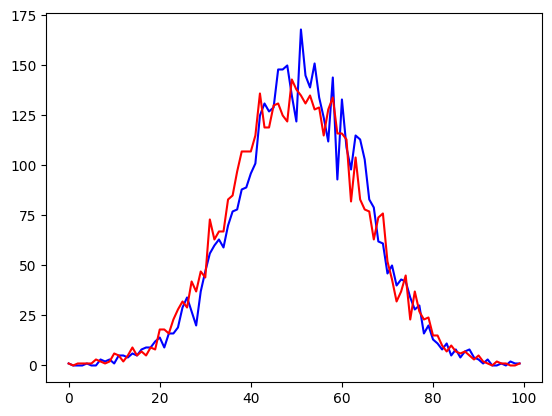

In [19]:
plt.plot(count, c='blue')
plt.plot(icount, c='red')

In [20]:
count = count / 5000

In [21]:
icount = icount / 5000

In [ ]:
kl(count, icount)

C:\Users\Taha\AppData\Local\Temp\ipykernel_6756\159355123.py:3: RuntimeWarning: divide by zero encountered in divide
  result = np.sum(np.where(np.logical_and(p != 0, q != 0), p * np.log(p / q), 0))
C:\Users\Taha\AppData\Local\Temp\ipykernel_6756\159355123.py:3: RuntimeWarning: invalid value encountered in divide
  result = np.sum(np.where(np.logical_and(p != 0, q != 0), p * np.log(p / q), 0))
C:\Users\Taha\AppData\Local\Temp\ipykernel_6756\159355123.py:3: RuntimeWarning: divide by zero encountered in log
  result = np.sum(np.where(np.logical_and(p != 0, q != 0), p * np.log(p / q), 0))
C:\Users\Taha\AppData\Local\Temp\ipykernel_6756\159355123.py:3: RuntimeWarning: invalid value encountered in multiply
  result = np.sum(np.where(np.logical_and(p != 0, q != 0), p * np.log(p / q), 0))


np.float64(0.018326180259768697)

: 

KL(p,q) =/= KL(q,p)

بخاطز همین نمیگن دیستنس یا قاصله میگن دایورجنس